In [1]:
%load_ext autoreload
%autoreload 2
import os, sys

import sys
sys.path.append("../../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.io
import mat73
from types import SimpleNamespace
import utils

from src.batch_experiments.utils import ExperimentAnalyser
from src.fmcw_simulation.simulation import FmcwRadar
from src.py_network.adaptive_resonate import AdaptiveResonate

plt.rc('xtick',labelsize=35)
plt.rc('ytick',labelsize=35)
# mpl.rcParams['figure.dpi'] = 200 
mpl.rcParams['figure.figsize'] = (12, 7) 
mpl.rcParams['axes.titlesize'] = 40
mpl.rcParams['axes.labelsize'] =35
mpl.rcParams['legend.fontsize'] = 30
plt.rcParams['lines.linewidth'] = 5.0
plt.rcParams['text.usetex'] = False
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#003052", "#C71818", "#18C7C7", "#70C718", "#7018C7"])
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#6ba0a6", "#d8584e", "#c09651", "#f8c08a", "#8e4f39"])

In [2]:
data_select = 2

In [3]:
Param = utils.get_radar_parameters(data_select)

In [4]:
radar_config = {
    "n_rx": 1,
    "fb" : Param.f0,
    "B" : Param.B,
    "n_chirps": Param.ntt_azimuth,
    "n_samples": Param.ntt_range,
    "t_chirp": Param.T_d,
    "IQ": True,
    "noise_std": 0.0
}
fmcw = FmcwRadar(radar_config)

In [5]:
data_choice = [6000, 12000, 18000]

In [6]:
data = utils.load_data_cascaded(f"../../data/delft_static_target/tuedata_6000/tuedata_{data_choice[data_select]}/")

In [7]:
data = data[-Param.ntt_azimuth:]

In [8]:
data_original = np.copy(data)

In [9]:
# data = fmcw.apply_hann(data[:, None])
data = data.squeeze()

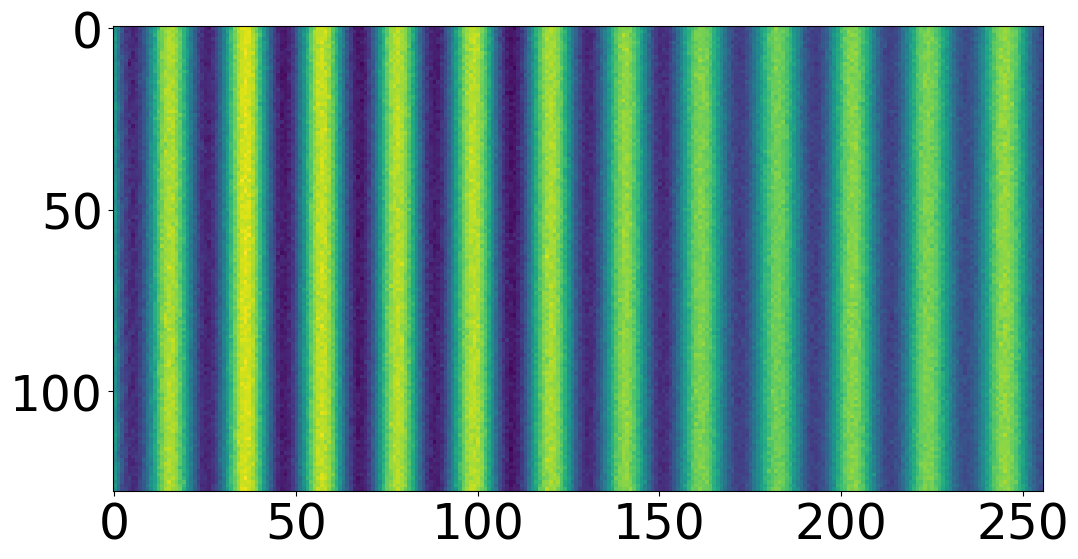

In [10]:
plt.imshow(np.real(data[:Param.ntt_azimuth]))

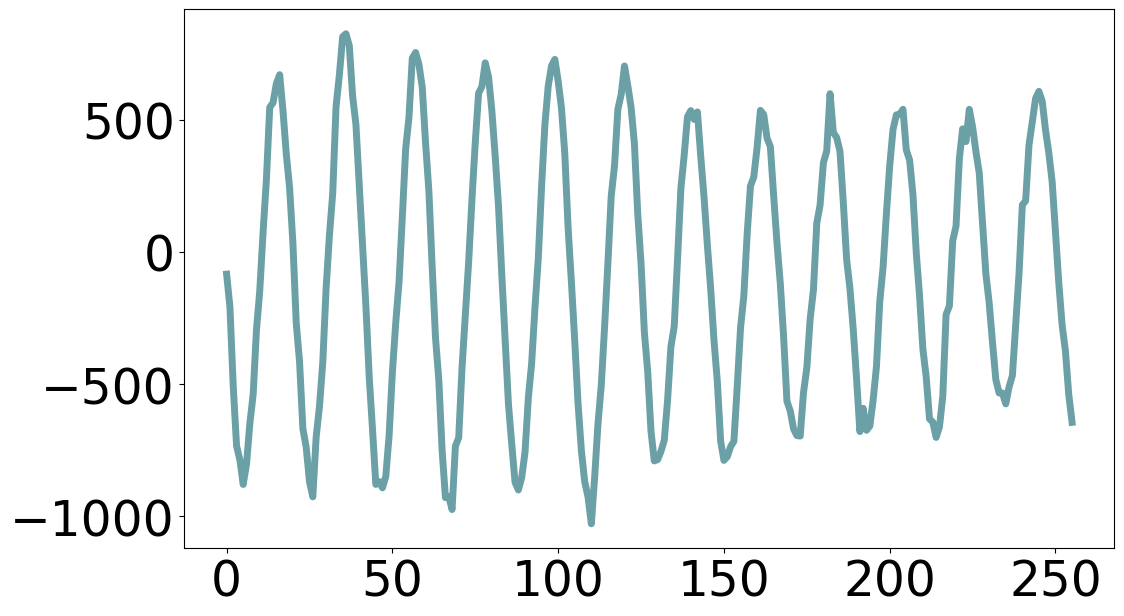

In [11]:
plt.plot(data[0, :].T.flatten().real)

In [12]:
data_fft_padd = np.zeros((data.shape[0], data.shape[1]), dtype=complex)
data_fft_padd[:, :data.shape[1]] = data_original[:, :]
np_fft = np.abs(np.fft.fft(data_fft_padd[-1]))

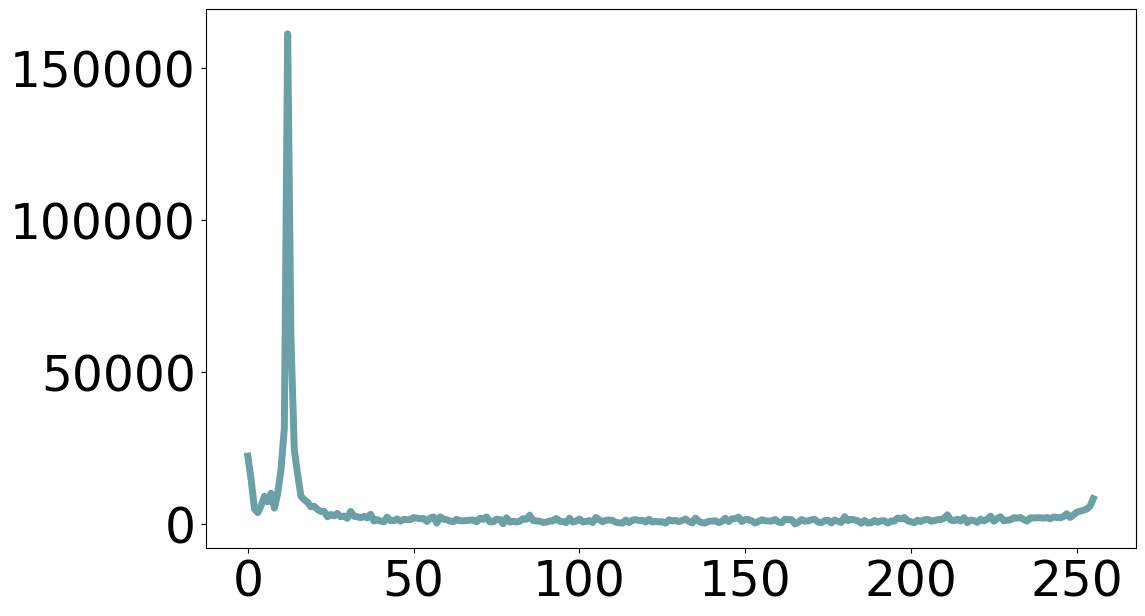

In [13]:
plt.plot(np_fft[:])

In [14]:
padded_freqs = np.fft.fftfreq(data_fft_padd.shape[1], fmcw.t_chirp / fmcw.n_samples)
np_argmax = np.abs(np_fft).argmax()
np_freq = padded_freqs[np_argmax]
np_freq

np.float64(843750.0)

In [15]:
n_units = 1
t_max = fmcw.t_chirp * fmcw.n_chirps
res_net = AdaptiveResonate(
            n_units, 
            t_max, 
            fmcw.t_chirp / fmcw.n_samples, 
            k=1,
            feedback=True,
            w_scale= np.ones((fmcw.n_rx, n_units))*Param.Ts*100*5,
            n_rxs=fmcw.n_rx
)

# res_net.spike_condition = res_net.period_spiking
res_net.normalize_input = False
res_net.normalize_neuron = True
res_net.spike_threshold = fmcw.get_freq_from_range(0.1)

min_starting_freq = 2
max_starting_freq = 30

res_net.set_starting_frequency(((np.linspace(3, 49, res_net.nfreq)) * 2 * np.pi) / fmcw.t_chirp)

In [16]:
padd_size = 0 #round((Param.T - Param.T_d) / res_net.t_res)
padded_data = np.zeros((data.shape[0], data.shape[1] + padd_size), dtype=complex)
padded_data[:, :data.shape[1]] = data

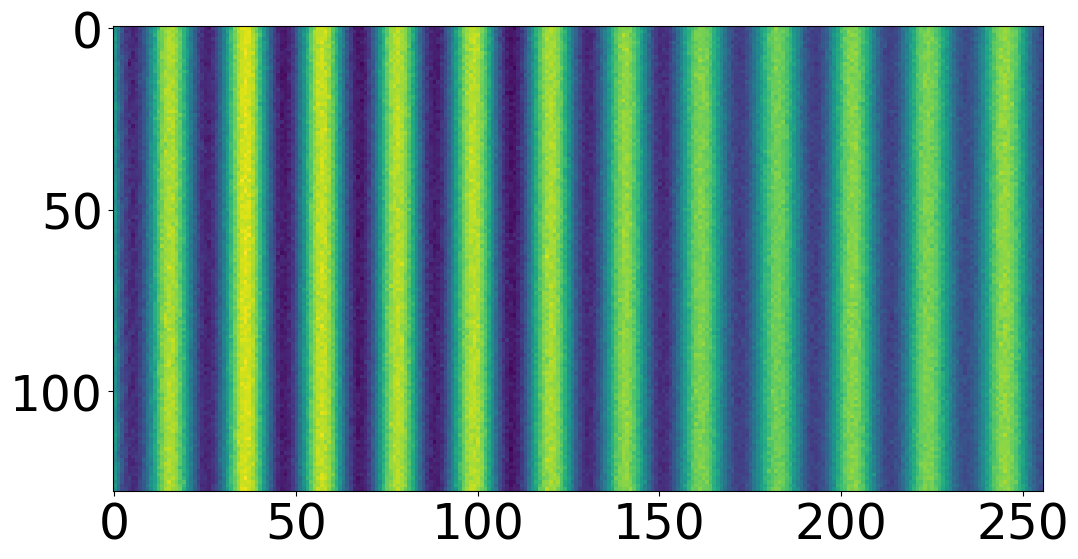

In [17]:
plt.imshow(padded_data.real)

In [18]:
input_signal = padded_data.reshape((1, -1))
input_signal /= np.abs(input_signal).max()
# we normalize the signal because the selected parameters expect a signal
# with amplitude ~1,-1. It does not need to be exact, but the given data is 500,-500
# alternatively one could also change the w_scale parameters, or k

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


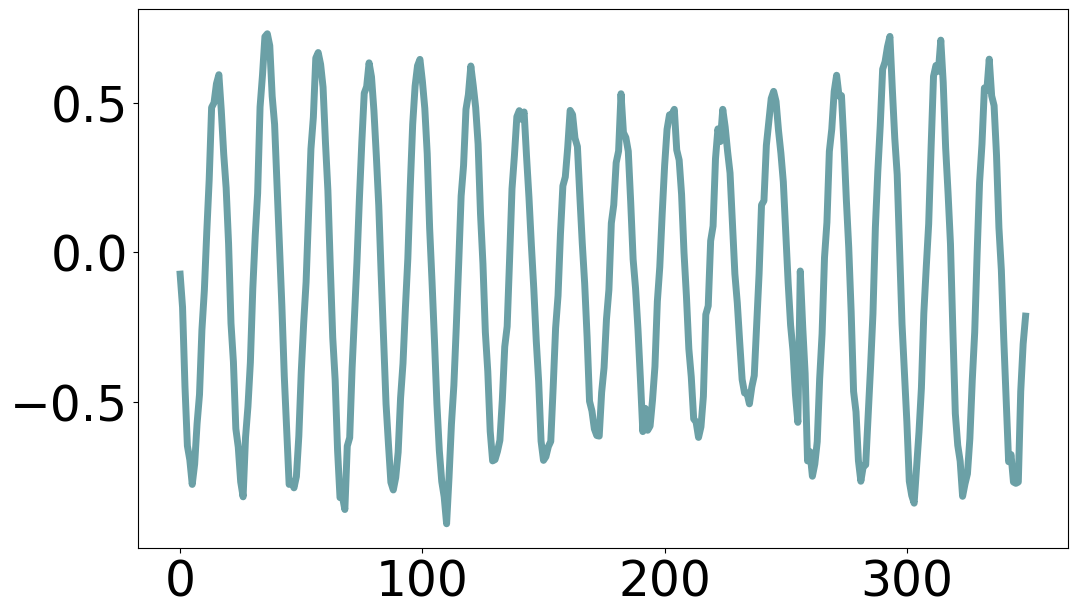

In [19]:
plt.plot(input_signal.flatten()[:350])

In [20]:
vs_hist, ws_hist = res_net.update_neurons_c(input_signal)

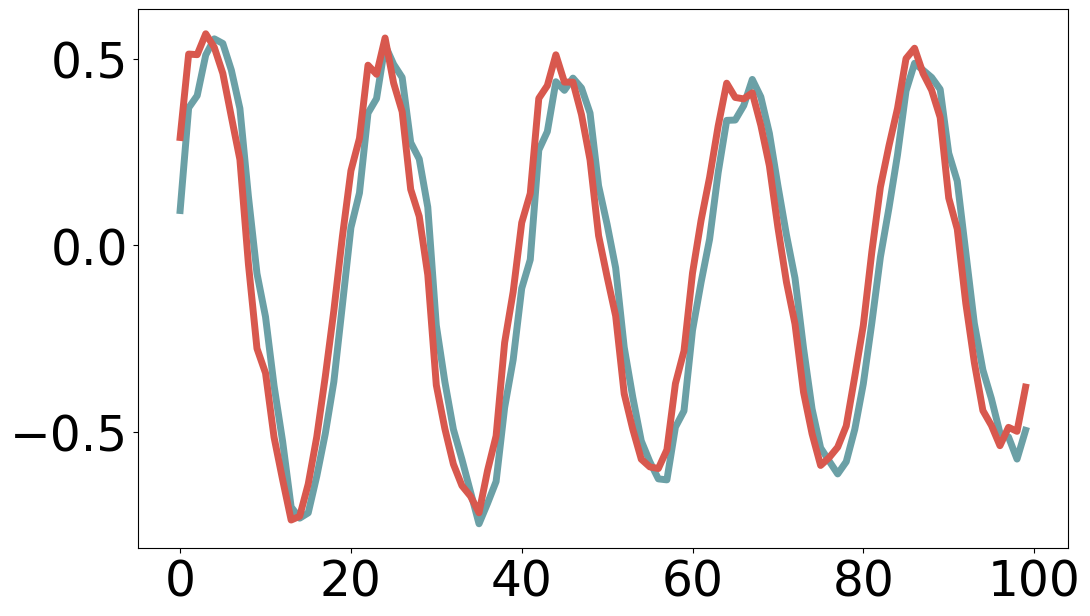

In [21]:
plt.plot(input_signal.flatten()[-2700:-2600])
plt.plot(vs_hist.flatten()[-2700:-2600])

In [22]:
freq_hist = ws_hist.squeeze() / (2*np.pi)

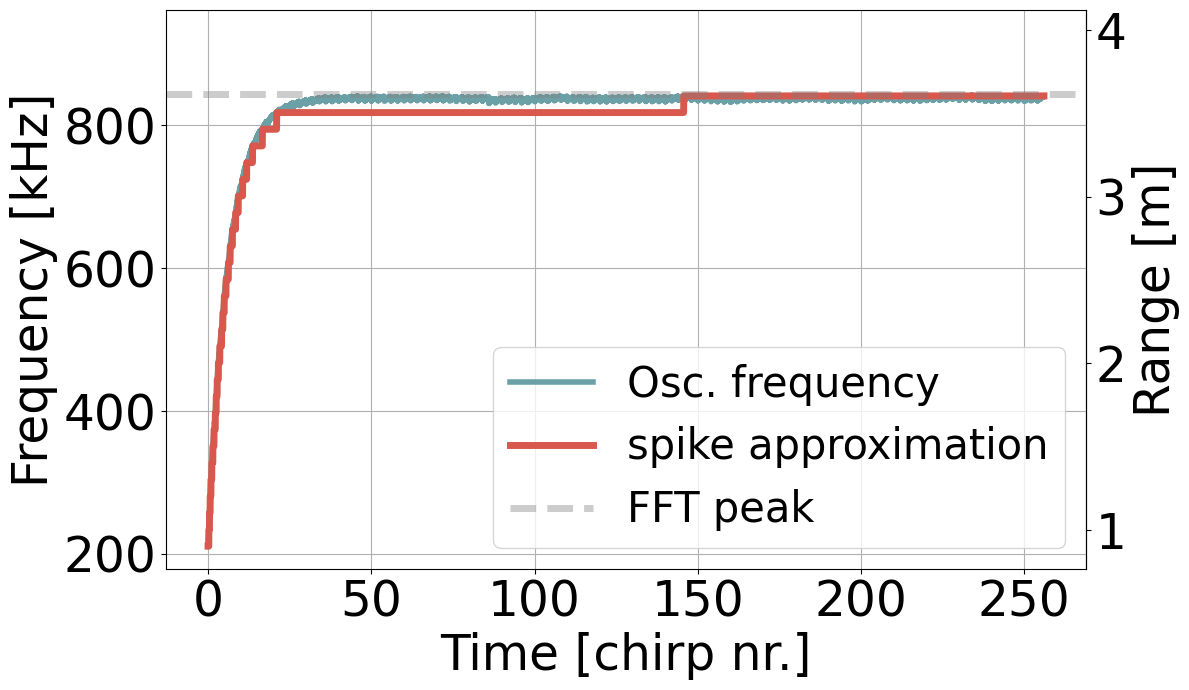

In [23]:
fig, ax = plt.subplots(1, figsize=(12, 7))

integrated_spikes = res_net.integrate_spikes()

time_chirps = np.linspace(0, data.shape[1], freq_hist.size)

ax.plot(time_chirps, freq_hist[:]*1e-3, linewidth=4, label="Osc. frequency")
ax.plot(time_chirps, integrated_spikes.squeeze() / (2 * np.pi) * 1e-3, label="spike approximation")
ax.axhline(padded_freqs[np_argmax]*1e-3, c="grey", linestyle="--", alpha=0.4, label="FFT peak")

ax.set_xlabel("Time [chirp nr.]")
ax.set_ylabel("Frequency [kHz]")
ax.grid()
ylim = ax.get_ylim()
ax.set_ylim([ylim[0], ylim[1]*1.1])
ax.legend()

secy = ax.secondary_yaxis('right', functions=(lambda x: fmcw.get_range_from_freq(x * 1e3), 
                                            lambda x: fmcw.get_freq_from_range(x) * 1e-3))
secy.set_ylabel("Range [m]")

plt.tight_layout()
plt.savefig("../paper_figures/real_data_convergence_180.pdf", bbox_inches='tight')

In [24]:
fft_argmax = padded_freqs[np_argmax]
fft_range = fmcw.get_range_from_freq(fft_argmax)

estimated_range_base = fmcw.get_range_from_freq(ws_hist[-1] / (2 * np.pi))
estimated_range_spikes = fmcw.get_range_from_freq(integrated_spikes[-1] / (2 * np.pi))

estimated_range_base = estimated_range_base.squeeze()
estimated_range_spikes = estimated_range_spikes.squeeze()

n_spikes = np.count_nonzero(res_net.spikes_out)

print(f"FFT range: {fft_range}\nexact frequency: {estimated_range_base}\nspike reconstruction: {estimated_range_spikes}")
print(f"number of spikes: {n_spikes}")

FFT range: 3.6160714285714293
exact frequency: 3.600438097478136
spike reconstruction: 3.604017857142857
number of spikes: 27


In [25]:
with open("single_target_measurements.txt", "a") as file:
    file.write(f"DATA {data_select}\n")
    file.write(f"FFT range: {fft_range}\nexact frequency: {estimated_range_base}\nspike reconstruction: {estimated_range_spikes}\n")
    file.write(f"number of spikes: {n_spikes}\n")
    file.write("------------------\n")

In [26]:
def plot_single_neuron_raster(ax, spikes_out, color):
    
    total_steps = spikes_out.size
    range_spikes_pos = np.nonzero(spikes_out > 0)[0]
    range_spikes_pos = range_spikes_pos / total_steps
    range_spikes_pos *= data.shape[1]

    range_spikes_neg = np.nonzero(spikes_out < 0)[0]
    range_spikes_neg = range_spikes_neg / total_steps
    range_spikes_neg *= data.shape[1]

    for sp in range_spikes_pos:
        ax.axvline(sp, ymin=0.5, ymax=0.95, c=color)
    for sn in range_spikes_neg:
        ax.axvline(sn, ymin=0.05, ymax=0.48, c=color)

    ax.axhline(0, c='grey', linewidth=2, linestyle=':')
    ax.set_ylim([-1, 1])
    ax.set_xlim([0, data.shape[1]])
    # Hide the right and top spines
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

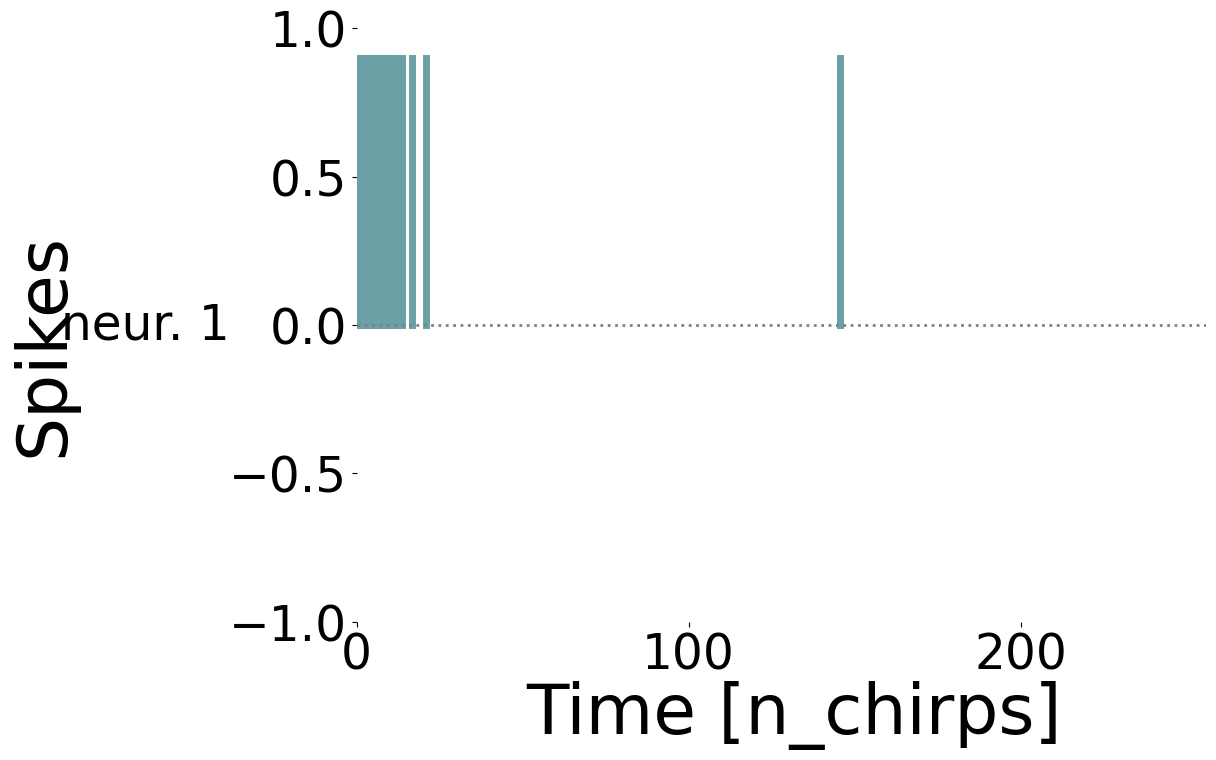

In [27]:
import matplotlib.transforms as mtrans

fig, ax = plt.subplots(1)

plot_single_neuron_raster(ax, res_net.spikes_out.squeeze(), color=f"C{0}")
ax.set_ylabel(f"neur. {1}", rotation='horizontal', labelpad=60, va='center')

fig.text(-0.03, 0.5, 'Spikes', va='center', rotation='vertical', fontsize=50)
fig.text(0.4, -0.03, 'Time [n_chirps]', va='center', fontsize=50)

plt.tight_layout()

plt.savefig("../paper_figures/real_chamber_data_spike_raster.pdf", bbox_inches='tight')

In [28]:
ffts_ranges = np.array([3.7165178571428568, 3.6160714285714284, 3.6160714285714293])
ffts_ranges.mean()

np.float64(3.649553571428571)

In [29]:
exact_ranges = np.array([3.6837338768192516, 3.638196056682557, 3.600438097478136])
exact_ranges.mean()

np.float64(3.6407893436599816)

In [30]:
recon = np.array([3.601339285714286, 3.6026785714285703, 3.604017857142857])
recon.mean()

np.float64(3.602678571428571)

In [31]:
n_spikes = np.array([33, 30, 27])
n_spikes.mean()

np.float64(30.0)